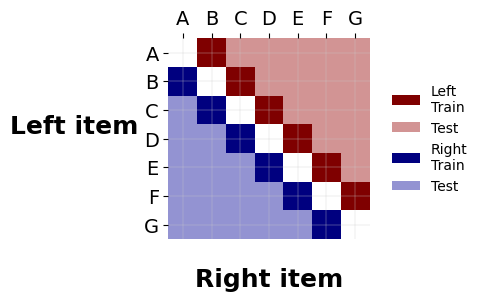

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

items = list("ABCDEFG")
n      = len(items)

# -----------------------------------------------------------------
# Build the condition matrix (same logic as before)
# -----------------------------------------------------------------
cond = np.empty((n, n), dtype=object)
for i in range(n):
    for j in range(n):
        if i == j:
            cond[i, j] = "diag"
        elif j > i:
            cond[i, j] = "left-train"  if j == i + 1 else "left-test"
        else:
            cond[i, j] = "right-train" if i == j + 1 else "right-test"

palette = {
    "left-train"  : "#7f0000",
    "left-test"   : "#d29494",
    "right-train" : "#00007f",
    "right-test"  : "#9393d2",
    "diag"        : "white",
}

# -----------------------------------------------------------------
# Draw
# -----------------------------------------------------------------
fig, ax = plt.subplots(figsize=(5, 5))

for (i, j), label in np.ndenumerate(cond):
    ax.add_patch(
        plt.Rectangle(
            (j, i), 1, 1,
            facecolor = palette[label],
            edgecolor = 'none',    # ← remove patch borders
            linewidth  = 0
        )
    )

ax.set_xlim(0, n);  ax.set_ylim(0, n)
ax.set_aspect("equal")
ax.invert_yaxis()

ax.set_xticks(np.arange(n) + 0.5)
ax.set_xticklabels(items, fontsize=14)
ax.xaxis.tick_top()
ax.set_xlabel("Right item", fontsize=18, weight="bold", labelpad=20)

ax.set_yticks(np.arange(n) + 0.5)
ax.set_yticklabels(items, fontsize=14)
ax.set_ylabel("Left item", fontsize=18, weight="bold", rotation=0, labelpad=50)

for spine in ax.spines.values():
    spine.set_visible(False)

ax.grid(color="0.8", linewidth=0.25)

legend_elements = [
    Patch(facecolor=palette["left-train"],  label="Left\nTrain"),
    Patch(facecolor=palette["left-test"],   label="Test"),
    Patch(facecolor=palette["right-train"], label="Right\nTrain"),
    Patch(facecolor=palette["right-test"],  label="Test"),
]
ax.legend(
    handles=legend_elements,
    frameon=False,
    bbox_to_anchor=(1.05, 0.5),
    loc="center left"
)

plt.tight_layout()
plt.show()


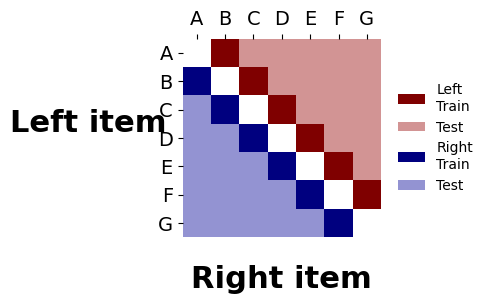

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# ------------------------------------------------------------
# 1. Define the items and condition matrix
# ------------------------------------------------------------
items = list("ABCDEFG")
n = len(items)

cond = np.empty((n, n), dtype=object)
for i in range(n):
    for j in range(n):
        if i == j:
            cond[i, j] = "diag"                       # white main diagonal
        elif j > i:                                   # upper-triangular
            cond[i, j] = "left-train"  if j == i + 1 else "left-test"
        else:                                         # lower-triangular
            cond[i, j] = "right-train" if i == j + 1 else "right-test"

# ------------------------------------------------------------
# 2. Colour palette
# ------------------------------------------------------------
palette = {
    "left-train"  : "#7f0000",   # dark red
    "left-test"   : "#d29494",   # light red
    "right-train" : "#00007f",   # dark blue
    "right-test"  : "#9393d2",   # light blue
    "diag"        : "white",
}

# ------------------------------------------------------------
# 3. Plotting
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(5, 5))

# draw colour squares *without* borders
for (i, j), label in np.ndenumerate(cond):
    ax.add_patch(
        plt.Rectangle(
            (j, i), 1, 1,
            facecolor=palette[label],
            edgecolor='none',     # ✅ no edges
            linewidth=0
        )
    )

# axes layout -------------------------------------------------
ax.set_xlim(0, n);  ax.set_ylim(0, n)
ax.set_aspect("equal")
ax.invert_yaxis()

ax.set_xticks(np.arange(n) + 0.5)
ax.set_xticklabels(items, fontsize=14)
ax.xaxis.tick_top()
ax.set_xlabel("Right item", fontsize=22, weight="bold", labelpad=20)

ax.set_yticks(np.arange(n) + 0.5)
ax.set_yticklabels(items, fontsize=14)
ax.set_ylabel("Left item", fontsize=22, weight="bold", rotation=0, labelpad=50)

for spine in ax.spines.values():
    spine.set_visible(False)

# legend ------------------------------------------------------
legend_elements = [
    Patch(facecolor=palette["left-train"],  label="Left\nTrain"),
    Patch(facecolor=palette["left-test"],   label="Test"),
    Patch(facecolor=palette["right-train"], label="Right\nTrain"),
    Patch(facecolor=palette["right-test"],  label="Test"),
]
ax.legend(
    handles=legend_elements,
    frameon=False,
    bbox_to_anchor=(1.02, 0.5),
    loc="center left"
)

plt.tight_layout()
plt.show()
# plt.savefig("train_test_matrix.png", dpi=300)   # <- uncomment to save


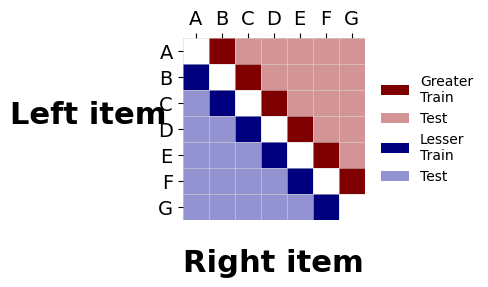

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# ------------------------------------------------------------
# 1. Items and condition matrix
# ------------------------------------------------------------
items = list("ABCDEFG")
n = len(items)

cond = np.empty((n, n), dtype=object)
for i in range(n):
    for j in range(n):
        if i == j:
            cond[i, j] = "diag"                       # white main diagonal
        elif j > i:                                   # upper-triangular
            cond[i, j] = "left-train"  if j == i + 1 else "left-test"
        else:                                         # lower-triangular
            cond[i, j] = "right-train" if i == j + 1 else "right-test"

# ------------------------------------------------------------
# 2. Colour palette
# ------------------------------------------------------------
palette = {
    "left-train"  : "#7f0000",   # dark red
    "left-test"   : "#d29494",   # light red
    "right-train" : "#00007f",   # dark blue
    "right-test"  : "#9393d2",   # light blue
    "diag"        : "white",
}

# ------------------------------------------------------------
# 3. Plot with a single, subtle grid
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(5, 5))

# 3-a  Draw coloured squares without borders
for (i, j), label in np.ndenumerate(cond):
    ax.add_patch(
        plt.Rectangle(
            (j, i), 1, 1,
            facecolor=palette[label],
            edgecolor='none',         # ← no patch edges
            linewidth=0
        )
    )

# 3-b  Add one uniform grid using minor ticks
ax.set_xticks(np.arange(n + 1), minor=True)
ax.set_yticks(np.arange(n + 1), minor=True)
ax.grid(which='minor', color='0.85', linewidth=0.4)   # subtle grey grid
ax.tick_params(which='minor', length=0)               # hide minor tick marks

# ------------------------------------------------------------
# 4. Cosmetic tweaks (labels, legend, etc.)
# ------------------------------------------------------------
ax.set_xlim(0, n);  ax.set_ylim(0, n)
ax.set_aspect("equal")
ax.invert_yaxis()

ax.set_xticks(np.arange(n) + 0.5)
ax.set_xticklabels(items, fontsize=14)
ax.xaxis.tick_top()
ax.set_xlabel("Right item", fontsize=22, weight="bold", labelpad=20)

ax.set_yticks(np.arange(n) + 0.5)
ax.set_yticklabels(items, fontsize=14)
ax.set_ylabel("Left item", fontsize=22, weight="bold", rotation=0, labelpad=50)

for spine in ax.spines.values():
    spine.set_visible(False)

legend_elements = [
    Patch(facecolor=palette["left-train"],  label="Greater\nTrain"),
    Patch(facecolor=palette["left-test"],   label="Test"),
    Patch(facecolor=palette["right-train"], label="Lesser\nTrain"),
    Patch(facecolor=palette["right-test"],  label="Test"),
]
ax.legend(
    handles=legend_elements,
    frameon=False,
    bbox_to_anchor=(1.02, 0.5),
    loc="center left"
)

plt.tight_layout()
plt.show()
# plt.savefig("train_test_matrix.png", dpi=300)  # save if desired


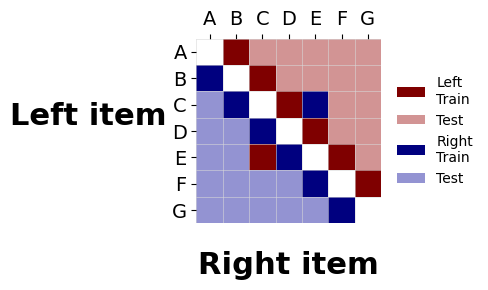

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# ------------------------------------------------------------
# 1. Items and base condition matrix
# ------------------------------------------------------------
items = list("ABCDEFG")          # A … G
n = len(items)

cond = np.empty((n, n), dtype=object)
for i in range(n):
    for j in range(n):
        if i == j:
            cond[i, j] = "diag"
        elif j > i:
            cond[i, j] = "left-train"  if j == i + 1 else "left-test"
        else:
            cond[i, j] = "right-train" if i == j + 1 else "right-test"

# ------------------------------------------------------------
# 2. Violation overrides  ------------------------------------
#    Pair(s) given as (left_item, right_item, new_label)
# ------------------------------------------------------------
violations = [
    ("C", "E", "right-train"),  # solid blue
    ("E", "C", "left-train"),   # solid red
]

for left, right, new_label in violations:
    i = items.index(left)
    j = items.index(right)
    cond[i, j] = new_label

# ------------------------------------------------------------
# 3. Colour palette
# ------------------------------------------------------------
palette = {
    "left-train"  : "#7f0000",   # dark red
    "left-test"   : "#d29494",   # light red
    "right-train" : "#00007f",   # dark blue
    "right-test"  : "#9393d2",   # light blue
    "diag"        : "white",
}

# ------------------------------------------------------------
# 4. Plot (Option 2: single faint grid)
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(5, 5))

# 4-a  coloured squares (no edges)
for (i, j), label in np.ndenumerate(cond):
    ax.add_patch(
        plt.Rectangle((j, i), 1, 1,
                      facecolor=palette[label],
                      edgecolor='none')
    )

# 4-b  draw one uniform grid
ax.set_xticks(np.arange(n + 1), minor=True)
ax.set_yticks(np.arange(n + 1), minor=True)
ax.grid(which='minor', color='0.85', linewidth=0.4)
ax.tick_params(which='minor', length=0)

# ------------------------------------------------------------
# 5. Labels, legend, cosmetics
# ------------------------------------------------------------
ax.set_xlim(0, n);  ax.set_ylim(0, n)
ax.set_aspect("equal")
ax.invert_yaxis()

ax.set_xticks(np.arange(n) + 0.5)
ax.set_xticklabels(items, fontsize=14)
ax.xaxis.tick_top()
ax.set_xlabel("Right item", fontsize=22, weight="bold", labelpad=20)

ax.set_yticks(np.arange(n) + 0.5)
ax.set_yticklabels(items, fontsize=14)
ax.set_ylabel("Left item", fontsize=22, weight="bold", rotation=0, labelpad=60)

for spine in ax.spines.values():
    spine.set_visible(False)

legend_elements = [
    Patch(facecolor=palette["left-train"],  label="Left\nTrain"),
    Patch(facecolor=palette["left-test"],   label="Test"),
    Patch(facecolor=palette["right-train"], label="Right\nTrain"),
    Patch(facecolor=palette["right-test"],  label="Test"),
]
ax.legend(handles=legend_elements,
          frameon=False,
          bbox_to_anchor=(1.02, 0.5),
          loc="center left")

plt.tight_layout()
plt.show()
# plt.savefig("train_test_matrix.png", dpi=300)


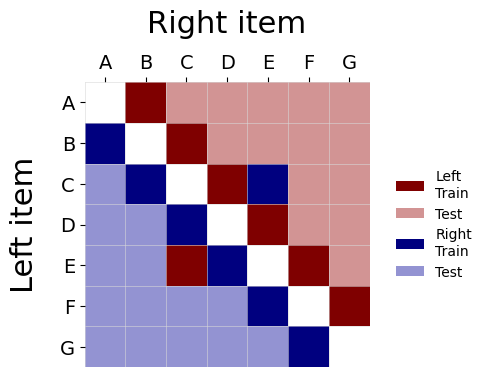

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# ------------------------------------------------------------
# 1. Items and base condition matrix
# ------------------------------------------------------------
items = list("ABCDEFG")
n = len(items)

cond = np.empty((n, n), dtype=object)
for i in range(n):
    for j in range(n):
        if i == j:
            cond[i, j] = "diag"
        elif j > i:
            cond[i, j] = "left-train"  if j == i + 1 else "left-test"
        else:
            cond[i, j] = "right-train" if i == j + 1 else "right-test"

# ------------------------------------------------------------
# 2. Violation overrides  (keep / extend as needed)
# ------------------------------------------------------------
violations = [
    ("C", "E", "right-train"),   # solid blue
    ("E", "C", "left-train"),    # solid red
]
for left, right, new_label in violations:
    cond[items.index(left), items.index(right)] = new_label

# ------------------------------------------------------------
# 3. Colour palette
# ------------------------------------------------------------
palette = {
    "left-train"  : "#7f0000",   # dark red
    "left-test"   : "#d29494",   # light red
    "right-train" : "#00007f",   # dark blue
    "right-test"  : "#9393d2",   # light blue
    "diag"        : "white",
}

# ------------------------------------------------------------
# 4. Plot (Option 2 → single faint grid)
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(5, 5))

# 4-a  draw coloured squares without borders
for (i, j), label in np.ndenumerate(cond):
    ax.add_patch(
        plt.Rectangle((j, i), 1, 1,
                      facecolor=palette[label],
                      edgecolor='none')
    )

# 4-b  one uniform grid
ax.set_xticks(np.arange(n + 1), minor=True)
ax.set_yticks(np.arange(n + 1), minor=True)
ax.grid(which='minor', color='0.85', linewidth=0.4)
ax.tick_params(which='minor', length=0)

# ------------------------------------------------------------
# 5. Axis ticks, limits, and *title positions*
# ------------------------------------------------------------
ax.set_xlim(0, n);  ax.set_ylim(0, n)
ax.set_aspect("equal")
ax.invert_yaxis()

# tick labels
ax.set_xticks(np.arange(n) + 0.5)
ax.set_xticklabels(items, fontsize=14)
ax.xaxis.tick_top()                       # put ticks at top

ax.set_yticks(np.arange(n) + 0.5)
ax.set_yticklabels(items, fontsize=14)

# axis titles exactly like the reference
ax.set_xlabel("Right item", fontsize=22, labelpad=15)
ax.xaxis.set_label_position('top')        # title *above* the letters

ax.set_ylabel("Left item",  fontsize=22, labelpad=15)
# default rotation=90 gives vertical text to the left of row labels

# remove outer spines
for spine in ax.spines.values():
    spine.set_visible(False)

# ------------------------------------------------------------
# 6. Legend
# ------------------------------------------------------------
legend_elements = [
    Patch(facecolor=palette["left-train"],  label="Left\nTrain"),
    Patch(facecolor=palette["left-test"],   label="Test"),
    Patch(facecolor=palette["right-train"], label="Right\nTrain"),
    Patch(facecolor=palette["right-test"],  label="Test"),
]
ax.legend(handles=legend_elements,
          frameon=False,
          bbox_to_anchor=(1.05, 0.5),
          loc="center left")

plt.tight_layout()

# Save the plot
plt.savefig("train_test_matrix.svg", format="svg")

plt.show()
# plt.savefig("train_test_matrix.png", dpi=300)   # save if you like
